In [182]:
import pandas as pd
import geopandas as gpd 
import requests 
import json
from datetime import datetime
from io import StringIO
import csv
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from shapely import wkt
from scipy.spatial.distance import cdist

import pandas as pd
import geopandas as gpd 
import requests 
import json
from datetime import datetime
from io import StringIO
import csv
import time
import os
import airqualityandclimateAPI
import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
from linearmodels import PanelOLS
import numpy as np

In [183]:
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)
from functools import partial
from sklearn.pipeline import Pipeline
# from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)

In [184]:
import Analysis
from Analysis import model_4_lasso_panel

In [185]:
import Final_LASSO
import Random_Forest 

In [186]:
totaldataframe = Analysis.totaldata()

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:87: DtypeWarning: Columns (8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  totaldf = pd.read_csv(totaldatapath)


# LASSO

#### Final LASSO using PM2.5

In [187]:
finallassopm = Final_LASSO.final_LASSO(totaldataframe, pm=True)


Non-numeric columns remaining: []
NaNs in X: 0
Initiating Shuffle Split:
Fitting Hyper Parameter Pipeline:


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.390e+03, tolerance: 1.892e+02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the s

Tuned alpha = 0.01295247137914592
Testing the Tuned Lasso with Cross Validation:
results saved
The non-zero coefficient estimates are:
                                        feature  coefficient
5                DailyMaximumDryBulbTemperature     1.714400
31                        CO2 Mass (short tons)     1.511161
30                        SO2 Mass (short tons)    -1.150008
37                                  sunrise_cos    -1.128472
4    DailyDepartureFromNormalAverageTemperature     1.084164
..                                          ...          ...
98         DailySustainedWindDirection_cos_lag2    -0.001576
108          DailyAverageWindDirection_sin_lag2    -0.001514
65           DailyAverageWindDirection_sin_lag1    -0.000828
96              DailyPeakWindDirection_cos_lag2    -0.000145
161                                   YEAR_lag3    -0.000033

[80 rows x 2 columns]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.707e+03, tolerance: 2.916e+02
  model = cd_fast.enet_coordinate_descent(


In [188]:
finallassofeaturespm = finallassopm[2]
finallassofeaturespm

['DailyMaximumDryBulbTemperature',
 'CO2 Mass (short tons)',
 'SO2 Mass (short tons)',
 'sunrise_cos',
 'DailyDepartureFromNormalAverageTemperature',
 'Sunrise_lag3',
 'AQlatitude',
 'DailyMinimumDryBulbTemperature_lag3',
 'sunrise_cos_lag1',
 'sunrise_cos_lag2',
 'sunrise_cos_lag3',
 'CO2 Mass (short tons)_lag3',
 'NUM_READS',
 'DailyMinimumDryBulbTemperature',
 'BUS_COUNT',
 'Sunrise',
 'sunset_cos',
 'DailyPeakWindSpeed_lag3',
 'NOx Mass (short tons)_lag3',
 'DailySustainedWindDirection_cos']

Correlation matrix for selected variables from PM LASSO: 

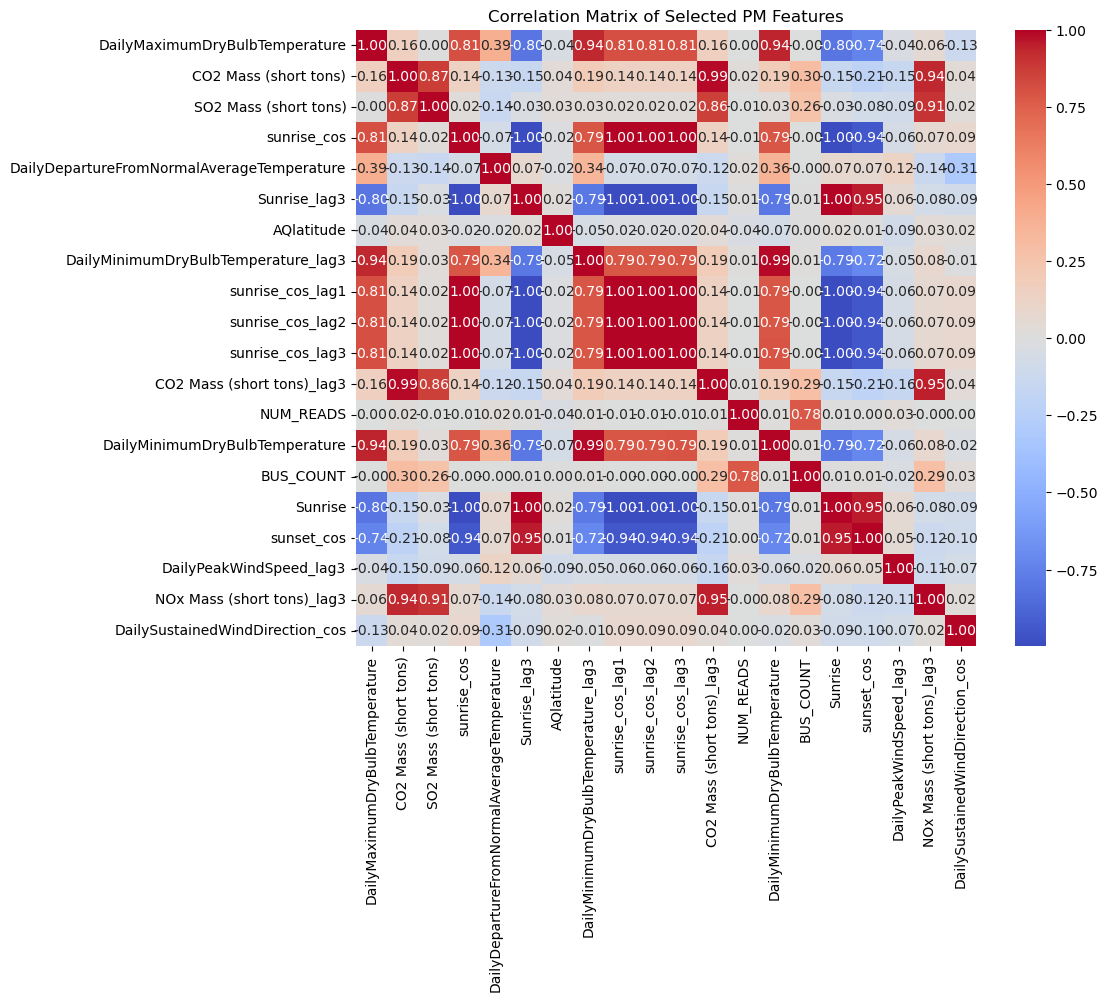

In [254]:
pmvars = totaldataframe[finallassofeaturespm]
pmvarscorr = pmvars.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(pmvarscorr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Selected PM Features')
plt.show()

#### Final LASSO using AQI

In [189]:
finallassoaqi = Final_LASSO.final_LASSO(totaldataframe, pm=False)
finallassofeaturesaqi = finallassoaqi[2]
finallassofeaturesaqi


Non-numeric columns remaining: []
NaNs in X: 0
Initiating Shuffle Split:
Fitting Hyper Parameter Pipeline:


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.530e+03, tolerance: 1.387e+03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the s

Tuned alpha = 0.050032627590710296
Testing the Tuned Lasso with Cross Validation:
results saved
The non-zero coefficient estimates are:
                                        feature  coefficient
5                DailyMaximumDryBulbTemperature     6.821557
4    DailyDepartureFromNormalAverageTemperature     4.129789
132         DailyMinimumDryBulbTemperature_lag3    -4.015636
31                        CO2 Mass (short tons)     3.987862
27                                   AQlatitude    -3.778697
..                                          ...          ...
96              DailyPeakWindDirection_cos_lag2    -0.005598
36                                  sunrise_sin    -0.005139
95              DailyPeakWindDirection_sin_lag2     0.003593
48                      DailyPrecipitation_lag1     0.002908
16                 DailyAverageAltimeterSetting     0.002848

[65 rows x 2 columns]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.236e+04, tolerance: 2.166e+03
  model = cd_fast.enet_coordinate_descent(


['DailyMaximumDryBulbTemperature',
 'DailyDepartureFromNormalAverageTemperature',
 'DailyMinimumDryBulbTemperature_lag3',
 'CO2 Mass (short tons)',
 'AQlatitude',
 'DailyMinimumDryBulbTemperature',
 'sunrise_cos',
 'sunset_cos_lag3',
 'NUM_READS',
 'SO2 Mass (short tons)',
 'BUS_COUNT',
 'sunrise_cos_lag1',
 'DailySustainedWindDirection_cos',
 'DailyPeakWindSpeed_lag3',
 'sunset_cos',
 'sunrise_cos_lag2',
 'AQlongitude',
 'CO2 Mass (short tons)_lag3',
 'DailyPeakWindSpeed',
 'DailyPeakWindDirection_sin']

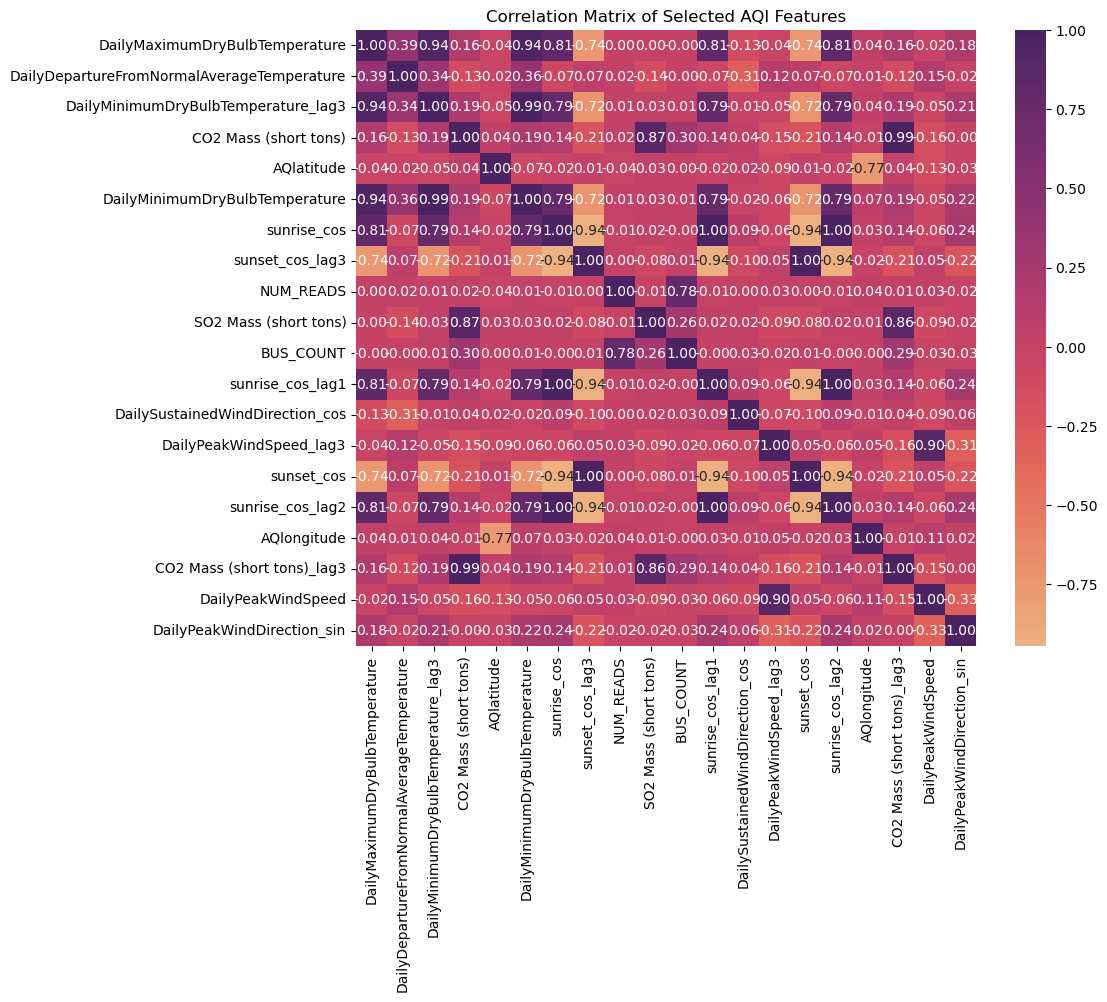

In [255]:
aqivars = totaldataframe[finallassofeaturesaqi]
aqivarscorr = aqivars.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(aqivarscorr, annot=True, cmap='flare', fmt='.2f')
plt.title('Correlation Matrix of Selected AQI Features')
plt.show()

In [190]:
xmatrixpm = finallassofeaturespm
xmatrixaqi = finallassofeaturesaqi

fe = ['CLIMATE_STATION_NAME','YEAR']
fe2 = ['CLIMATE_STATION_NAME','YEAR','AQ_STATION_NAME']

y_pm = ['arithmetic_mean']
y_aqi = ['aqi']

# xvars = ['Number', 'Capacity']
xvarsnum = ['Number']
xvarscap = ['Capacity']

## X variables using the PM results: 
x_pm_num = xvarsnum + xmatrixpm
x_pm_cap = xvarscap + xmatrixpm

## X variables using the AQIQ results:
x_aqi_num = xvarsnum + xmatrixaqi
x_aqi_cap = xvarscap + xmatrixaqi

# totalcols = x+y

OLS LASSO PM using Number of gens:

In [191]:
OLS_PM_NUM = model_4_lasso_panel(totaldataframe, x_pm_num, y_pm, fe)
print(OLS_PM_NUM)

                          PanelOLS Estimation Summary                           
Dep. Variable:        arithmetic_mean   R-squared:                        0.1407
Estimator:                   PanelOLS   R-squared (Between):             -0.9453
No. Observations:               72978   R-squared (Within):               0.1431
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.1421
Time:                        13:05:59   Log-likelihood                -2.316e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      746.35
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(16,72951)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):          1.508e+16
                            

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:780: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


OLS LASSO PM using Daily sum of added gen capacity 

In [192]:
OLS_PM_CAP = model_4_lasso_panel(totaldataframe, x_pm_cap, y_pm , fe)
print(OLS_PM_CAP)

                          PanelOLS Estimation Summary                           
Dep. Variable:        arithmetic_mean   R-squared:                        0.1407
Estimator:                   PanelOLS   R-squared (Between):             -0.9478
No. Observations:               72978   R-squared (Within):               0.1432
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.1422
Time:                        13:06:07   Log-likelihood                -2.316e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      746.57
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(16,72951)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):         -2.878e+17
                            

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:780: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunrise_cos_lag2, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


OLS AQI using Number:

In [193]:
OLS_AQI_NUM = model_4_lasso_panel(totaldataframe, x_aqi_num, y_aqi, fe)
print(OLS_AQI_NUM)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    aqi   R-squared:                        0.2632
Estimator:                   PanelOLS   R-squared (Between):              0.3988
No. Observations:               72978   R-squared (Within):               0.2559
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.2564
Time:                        13:06:20   Log-likelihood                -2.992e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1629.1
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(16,72951)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):          2.806e+16
                            

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:780: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


OLS AQI using Capacity:


In [194]:
OLS_AQI_CAP = model_4_lasso_panel(totaldataframe, x_aqi_cap, y_aqi, fe)
print(OLS_AQI_CAP) 

                          PanelOLS Estimation Summary                           
Dep. Variable:                    aqi   R-squared:                        0.2633
Estimator:                   PanelOLS   R-squared (Between):              0.3984
No. Observations:               72978   R-squared (Within):               0.2562
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.2566
Time:                        13:06:35   Log-likelihood                -2.992e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1629.9
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(16,72951)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):         -3.814e+18
                            

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:780: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunset_cos_lag3, sunrise_cos_lag1, sunset_cos

  results = model.fit(cov_type='clustered', cluster_entity=True)


# AQ Station Fixed Effects 

OLS AQI using Num and AQ STATION FE:

In [195]:
aq_station_dummies = pd.get_dummies(totaldataframe['AQ_STATION_NAME'],prefix='AQ_STATION_NAME',drop_first = True)
totaldataframe2 = pd.concat([totaldataframe, aq_station_dummies], axis=1)

x_aqi_num_aq = x_aqi_num + list(aq_station_dummies.columns)
x_aqi_cap_aq = x_aqi_cap + list(aq_station_dummies.columns)

print(len(list(aq_station_dummies.columns)))

print(len(totaldataframe['AQ_STATION_NAME'].unique()))



11
12


In [196]:
OLS_AQI_NUM_AQ = model_4_lasso_panel(totaldataframe2, x_aqi_num_aq, y_aqi, fe)
print(OLS_AQI_NUM_AQ)

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:780: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunset_cos, AQ_STATION_NAME_REGIONAL OFFICE BUILDING, AQ_STATION_NAME_VILLAGE HALL, AQ_STATION_NAME_WASHINGTON HS

  results = model.fit(cov_type='clustered', cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                    aqi   R-squared:                        0.2765
Estimator:                   PanelOLS   R-squared (Between):          -5.149e+04
No. Observations:               72978   R-squared (Within):               0.2746
Date:                Tue, Apr 21 2026   R-squared (Overall):             -171.70
Time:                        13:06:48   Log-likelihood                -2.985e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1115.3
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(25,72942)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):         -6.395e+15
                            

Note that adding the aq-station fixed effects increased the coefficient on the Number of generators and also increased the R-squared representing the model's fit 

OLS AQI using Capacity and AQ STATION FE:

In [177]:
OLS_AQI_CAP_AQ = model_4_lasso_panel(totaldataframe2, x_aqi_cap_aq, y_aqi, fe)
print(OLS_AQI_CAP_AQ)

/Users/griffinberonio/Documents/AAE 724/AAE-724-Repo/Analysis.py:780: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

sunrise_cos, sunrise_cos_lag1, sunset_cos, AQ_STATION_NAME_REGIONAL OFFICE BUILDING, AQ_STATION_NAME_VILLAGE HALL, AQ_STATION_NAME_WASHINGTON HS

  results = model.fit(cov_type='clustered', cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                    aqi   R-squared:                        0.2766
Estimator:                   PanelOLS   R-squared (Between):          -5.161e+04
No. Observations:               72978   R-squared (Within):               0.2748
Date:                Tue, Apr 21 2026   R-squared (Overall):             -172.09
Time:                        01:09:15   Log-likelihood                -2.985e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1115.8
Entities:                           2   P-value                           0.0000
Avg Obs:                    3.649e+04   Distribution:                F(25,72942)
Min Obs:                    3.575e+04                                           
Max Obs:                    3.723e+04   F-statistic (robust):         -3.172e+17
                            

# Random Forest ________________________

Random Forest using PM:

In [21]:
random_forest_pm = Random_Forest.random_forest(totaldataframe, pm=True)

Number of NaNs in X: 0
Preprocessing setup complete.
Fitting the Grid Search for RF hyperparameter tuning...
100
Fitting the RF model
(51082, 168)
                                             feature  importance
112                       SO2 Mass (short tons)_lag2    0.014460
139                  DailyPeakWindDirection_cos_lag3    0.013461
4         DailyDepartureFromNormalAverageTemperature    0.013183
80                                         DATE_lag2    0.012534
130  DailyDepartureFromNormalAverageTemperature_lag3    0.011551
114                       NOx Mass (short tons)_lag2    0.011299
156                       CO2 Mass (short tons)_lag3    0.010971
98              DailySustainedWindDirection_cos_lag2    0.010831
36                                       sunrise_sin    0.010700
10                                           Sunrise    0.010583
29                                  Gross Load (MWh)    0.010549
44   DailyDepartureFromNormalAverageTemperature_lag1    0.010475
0       

In [25]:
random_forest_pm[3].head(20)

,feature,importance
112,SO2 Mass (short tons)_lag2,0.014460
139,DailyPeakWindDirection_cos_lag3,0.013461
4,DailyDepartureFromNormalAverageTemperature,0.013183
80,DATE_lag2,0.012534
130,DailyDepartureFromNormalAverageTemperature_lag3,0.011551
114,NOx Mass (short tons)_lag2,0.011299
156,CO2 Mass (short tons)_lag3,0.010971
98,DailySustainedWindDirection_cos_lag2,0.010831
36,sunrise_sin,0.010700
10,Sunrise,0.010583


Random Forest using AQI:


In [ ]:
random_forest_aqi = Random_Forest.random_forest(totaldataframe, pm=False)


Number of NaNs in X: 0
Preprocessing setup complete.
Fitting the Grid Search for RF hyperparameter tuning...
100
Fitting the RF model
(51082, 168)
                                             feature  importance
4         DailyDepartureFromNormalAverageTemperature    0.016058
44   DailyDepartureFromNormalAverageTemperature_lag1    0.015018
87   DailyDepartureFromNormalAverageTemperature_lag2    0.013881
53                   DailyPeakWindDirection_cos_lag1    0.013785
130  DailyDepartureFromNormalAverageTemperature_lag3    0.013110
98              DailySustainedWindDirection_cos_lag2    0.012847
139                  DailyPeakWindDirection_cos_lag3    0.012210
96                   DailyPeakWindDirection_cos_lag2    0.011879
55              DailySustainedWindDirection_cos_lag1    0.011819
15                   DailySustainedWindDirection_cos    0.011058
141             DailySustainedWindDirection_cos_lag3    0.010765
88               DailyMaximumDryBulbTemperature_lag2    0.010588
80      

In [24]:
random_forest_aqi[3].head(20)

,feature,importance
4,DailyDepartureFromNormalAverageTemperature,0.016058
44,DailyDepartureFromNormalAverageTemperature_lag1,0.015018
87,DailyDepartureFromNormalAverageTemperature_lag2,0.013881
53,DailyPeakWindDirection_cos_lag1,0.013785
130,DailyDepartureFromNormalAverageTemperature_lag3,0.013110
98,DailySustainedWindDirection_cos_lag2,0.012847
139,DailyPeakWindDirection_cos_lag3,0.012210
96,DailyPeakWindDirection_cos_lag2,0.011879
55,DailySustainedWindDirection_cos_lag1,0.011819
15,DailySustainedWindDirection_cos,0.011058


# Making Tables

In [26]:
import os
from stargazer.stargazer import Stargazer, LineLocation


Table 1. LASSO OLS results for PM mean on LASSO Selected vars and Renewables

In [37]:
def sig_vars(model_name):
    p_values = model_name.pvalues

    # Filter for variables where p < 0.05 (or your chosen threshold)
    significant_vars = p_values[p_values < 0.05].index.tolist()

    # If the 'intercept' or 'const' is significant but you want to hide it, 
    # you can remove it from the list manually:
    if 'const' in significant_vars:
        significant_vars.remove('const')
    
    return significant_vars

In [265]:
rename_dict = {
    "DailyAverageDryBulbTemperature":      "Daily Average Dry Bulb Temperature",
    "DailyAverageDewPointTemperature":  "Daily Average Dew Point Temperature",
    "DailyAveragePrecipitation": "Daily Average Precipitation",
    "DailyAveragePressureChange":     "Daily Average Pressure Change",
    "DailyAverageRelativeHumidity":     "Daily Average Relative Humidity",
    "DailyAverageSeaLevelPressure":     "Daily Average Sea Level Pressure",
    "DailyAverageStationPressure":     "Daily Average Station Pressure",
    "DailyAverageWetBulbTemperature":     "Daily Average Wet Bulb Temperature",
    "DailyAverageWindDirection_cos":     "Daily Average Wind Direction (cosine)",
    "DailyAverageWindDirection_sin":     "Daily Average Wind Direction (sine)",
    "DailyAverageWindGustSpeed":     "Daily Average Wind Gust Speed",
    "DailyAverageWindSpeed":     "Daily Average Wind Speed",
    "DailyDepartureFromNormalAverageTemperature":     "Daily Departure from Normal Average Temperature",
    "DailyMaximumDryBulbTemperature":     "Daily Maximum Dry Bulb Temperature",
    "DailyMinimumDryBulbTemperature":     "Daily Minimum Dry Bulb Temperature",
    "DailyPeakWindDirection_cos":     "Daily Peak Wind Direction (cosine)",
    "DailyPeakWindSpeed":     "Daily Peak Wind Speed",
    "DailyPrecipitation":     "Daily Precipitation",
    "DailySustainedWindDirection_cos":     "Daily Sustained Wind Direction (cosine)",
    "DailySustainedWindDirection_sin":     "Daily Sustained Wind Direction (sine)",
    "DailySustainedWindSpeed":     "Daily Sustained Wind Speed",
    "Number": "Number of Renewable Generators Added",
    "CO2 Mass (short tons)_lag3": "CO2 Mass (short tons) Lagged 3 Days",
    "NUM_READS": "Number of Traffic GPS Signals",
    "BUS_COUNT": "Number of Buses",
    "DailyPeakWindSpeed_lag3": "Daily Peak Wind Speed Lagged 3 Days",
    "NOx Mass (short tons)_lag3	": "NOx Mass (short tons) Lagged 3 Days",
    "DailyMinimumDryBulbTemperature_lag3	": "Daily Minimum Dry Bulb Temperature Lagged 3 Days",
    "AQlatitude": "AQ Station Latitude",
    "DailyPeakWindDirection_sin": "Daily Peak Wind Direction (sine)",
    "AQlongitude": "AQ Station Longitude",
    "sunrise_cos_lag2": "Cosine of Sunrise Time Lagged 2 Days",
    "DailyMinimumDryBulbTemperature_lag3": "Daily Minimum Dry Bulb Temperature Lagged 3 Days"
    
    

}

In [178]:

star1 = Stargazer([OLS_PM_NUM])

star1.title("Table 1. Average PM 2.5 on Number of Generators and LASSO-Selected Variables (LASSO to Panel OLS)")
star1.custom_columns(["LASSO 2"], [1])
star1.covariate_order(sig_vars(OLS_PM_NUM))  # Only include significant variables in the table
star1.dependent_variable_name("Average PM 2.5 (µg/m³)")
star1.rename_covariates(rename_dict)
star1.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
star1.show_degrees_of_freedom(False)

star1.add_line(
    "Standard errors",
    ["Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
star1.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

star1


Table 2: Results for PM 2.5 on Capacity and LASSO-selected variables:

In [64]:

star2 = Stargazer([OLS_PM_CAP])

star2.title("Table 2. Average PM 2.5 on Added Capacity and LASSO-Selected Variables (LASSO to Panel OLS)")
star2.custom_columns(["LASSO 2"], [1])
star2.covariate_order(sig_vars(OLS_PM_CAP))  # Only include significant variables in the table
star2.dependent_variable_name("Average PM 2.5 (µg/m³)")
star2.rename_covariates(rename_dict)
star2.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
star2.show_degrees_of_freedom(False)

star2.add_line(
    "Standard errors",
    ["Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
star2.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

star2

LASSO 3: AQI on Number of Renewables 

In [65]:
star3 = Stargazer([OLS_AQI_NUM])

star3.title("Table 3. AQI on Number of Generators and LASSO-Selected Variables (LASSO to Panel OLS)")
star3.custom_columns(["LASSO 3"], [1])
star3.covariate_order(sig_vars(OLS_AQI_NUM))  # Only include significant variables in the table
star3.dependent_variable_name("Average AQI")
star3.rename_covariates(rename_dict)
star3.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
star3.show_degrees_of_freedom(False)

star3.add_line(
    "Standard errors",
    ["Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
star3.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

star3

LASSO 4: AQI on Daily Capacity Added and LASSO-selected Variables:

In [77]:
star4 = Stargazer([OLS_AQI_CAP])

star4.title("<b>Table 4. AQI on Capacity and LASSO-Selected Variables (LASSO to Panel OLS)</b>")
star4.custom_columns(["LASSO 4"], [1])
star4.covariate_order(sig_vars(OLS_AQI_CAP))  # Only include significant variables in the table
star4.dependent_variable_name("Average AQI")
star4.rename_covariates(rename_dict)
star4.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
star4.show_degrees_of_freedom(False)

star4.add_line(
    "Standard errors",
    ["Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
star4.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

star4

In [271]:
#Saving tables from Panel OLS regressions for Regression Model I:

dir = '/Users/griffinberonio/Documents/AAE 724/Tables'
i = 0
for table in [star1, star2, star3, star4]:
    i += 1
    table_name = f"LASSO_{i}"
    html_path = os.path.join(dir, f"{table_name}.html")
    with open(html_path, 'w') as f:
        f.write(table.render_html())


# Random Forest Tables 

In [ ]:
rf_aqi = random_forest_aqi[3].head(20).reset_index(drop=True)
# rf_aqi = rf_aqi.drop(['Index'])
rf_aqi['importance'] = rf_aqi['importance'].round(3)
rf_aqi

,feature,importance
0,DailyDepartureFromNormalAverageTemperature,0.016
1,DailyDepartureFromNormalAverageTemperature_lag1,0.015
2,DailyDepartureFromNormalAverageTemperature_lag2,0.014
3,DailyPeakWindDirection_cos_lag1,0.014
4,DailyDepartureFromNormalAverageTemperature_lag3,0.013
5,DailySustainedWindDirection_cos_lag2,0.013
6,DailyPeakWindDirection_cos_lag3,0.012
7,DailyPeakWindDirection_cos_lag2,0.012
8,DailySustainedWindDirection_cos_lag1,0.012
9,DailySustainedWindDirection_cos,0.011


In [301]:
rf_pm = random_forest_pm[3].head(20).reset_index(drop=True)
rf_pm['importance'] = rf_pm['importance'].round(3)
rf_pm

,feature,importance
0,SO2 Mass (short tons)_lag2,0.014
1,DailyPeakWindDirection_cos_lag3,0.013
2,DailyDepartureFromNormalAverageTemperature,0.013
3,DATE_lag2,0.013
4,DailyDepartureFromNormalAverageTemperature_lag3,0.012
5,NOx Mass (short tons)_lag2,0.011
6,CO2 Mass (short tons)_lag3,0.011
7,DailySustainedWindDirection_cos_lag2,0.011
8,sunrise_sin,0.011
9,Sunrise,0.011


In [302]:
dir = '/Users/griffinberonio/Documents/AAE 724/Tables'
i = 0
lis = [rf_aqi, rf_pm]
for table in lis:
    i += 1
    table_name = f"Random_Forest_Features_{i}"
    tex_path = os.path.join(dir, f"{table_name}.tex")
    with open(tex_path, 'w') as f:
        f.write(table.to_latex())

In [103]:
# Top coefficient dot and whisker plot for PM 2.5 on number of generators added:
OLS_PM_NUM.conf_int().head()

,lower,upper
Number,-0.001199,-0.000738
DailyMaximumDryBulbTemperature,0.073507,0.180416
CO2 Mass (short tons),0.000028,0.000032
SO2 Mass (short tons),-0.016081,-0.014890
DailyDepartureFromNormalAverageTemperature,0.227416,0.361892


In [141]:

paramseries = OLS_PM_NUM.params.head()
# Use confidence intervals to calculate error bars for the top 5 parameters:

conf5 = OLS_PM_NUM.conf_int().head()
error_series = paramseries - conf5['lower']
error_series

coef_df = pd.DataFrame({'coef': paramseries,
                        'err': error_series,
                        'varname': paramseries.index
                       })
coef_df

rename_dict = {"Number": "Number of Renewables",
               "DailyMaximumDryBulbTemperature": "Daily Max Temp",
               "DailyMinimumDryBulbTemperature": "Daily Min Temp",
               "DailyDepartureFromNormalAverageTemperature": "Departure from Normal Temp"}
coef_df['varname'] = coef_df['varname'].map(rename_dict).fillna(coef_df['varname'])
coef_df

,coef,err,varname
Number,-0.000969,0.000231,Number of Renewables
DailyMaximumDryBulbTemperature,0.126961,0.053454,Daily Max Temp
CO2 Mass (short tons),0.000030,0.000002,CO2 Mass (short tons)
SO2 Mass (short tons),-0.015485,0.000595,SO2 Mass (short tons)
DailyDepartureFromNormalAverageTemperature,0.294654,0.067238,Departure from Normal Temp


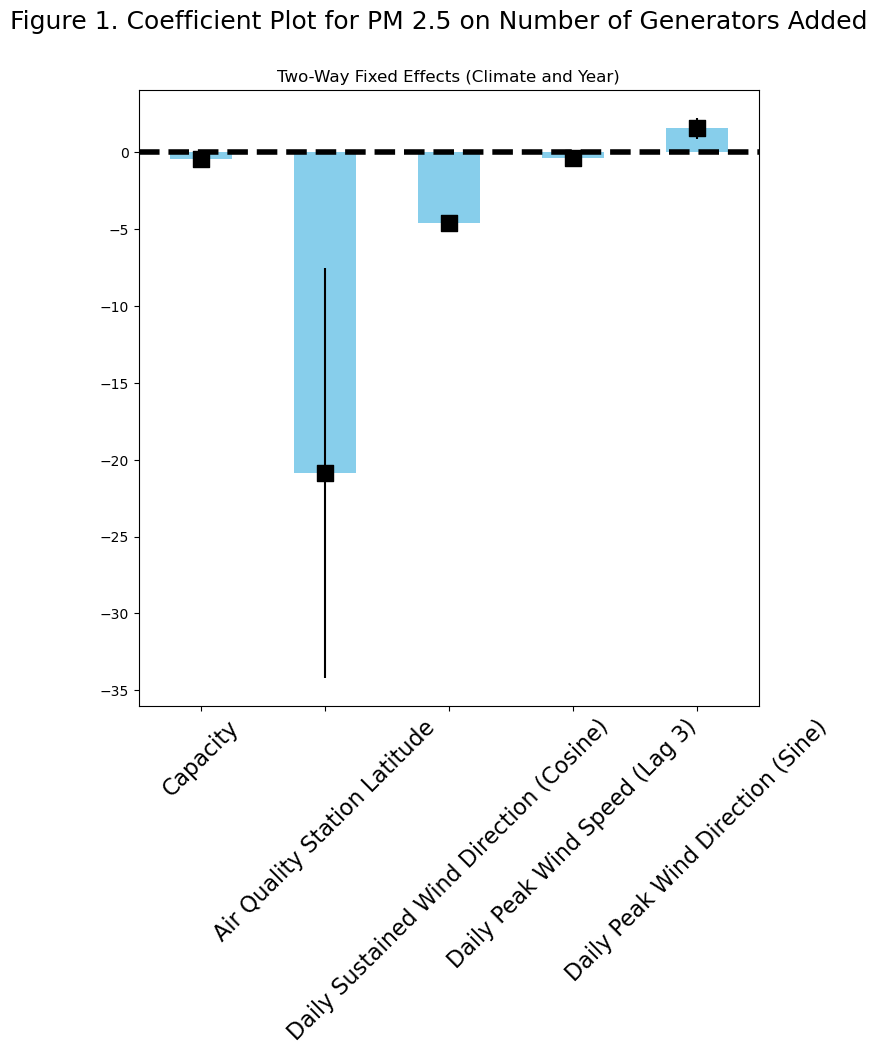

In [276]:
fig, ax = plt.subplots(figsize=(8, 8))
coef_df.plot(x='varname', y='coef', kind='bar', 
             ax=ax, color='skyblue', 
             yerr='err', legend=False)
ax.set_ylabel('')
ax.set_xlabel('')
ax.scatter(x=np.arange(coef_df.shape[0]), 
           marker='s', s=120, 
           y=coef_df['coef'], color='black')
ax.axhline(y=0, linestyle='--', color='black', linewidth=4)
_ = ax.set_xticklabels(coef_df['varname'],
                       rotation=45, fontsize=16)

plt.suptitle("Figure 1. Coefficient Plot for PM 2.5 on Number of Generators Added", fontsize=18)
ax.set_title("Two-Way Fixed Effects (Climate and Year)")

fs = 16
# ax.annotate('Control', xy=(0.3, -0.2), xytext=(0.3, -0.3), 
#             xycoords='axes fraction', 
#             textcoords='axes fraction', 
#             fontsize=fs, ha='center', va='bottom',
#             bbox=dict(boxstyle='square', fc='white', ec='black'),
#             arrowprops=dict(arrowstyle='-[, widthB=6.5, lengthB=1.2', lw=2.0, color='black'))

# _ = ax.annotate('Study', xy=(0.8, -0.2), xytext=(0.8, -0.3), 
#                  xycoords='axes fraction', 
#                  textcoords='axes fraction', 
#                  fontsize=fs, ha='center', va='bottom',
#                  bbox=dict(boxstyle='square', fc='white', ec='black'),
#                  arrowprops=dict(arrowstyle='-[, widthB=3.5, lengthB=1.2', lw=2.0, color='black'))

In [198]:
# AQI on Capacity Dot and whisker plot:
OLS_AQI_CAP

Dep. Variable:,aqi,R-squared:,0.2633
Estimator:,PanelOLS,R-squared (Between):,0.3984
No. Observations:,72978,R-squared (Within):,0.2562
Date:,"Tue, Apr 21 2026",R-squared (Overall):,0.2566
Time:,13:06:35,Log-likelihood,-2.992e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,1629.9
Entities:,2,P-value,0.0000
Avg Obs:,3.649e+04,Distribution:,"F(16,72951)"
Min Obs:,3.575e+04,,
Max Obs:,3.723e+04,F-statistic (robust):,-3.814e+18


In [199]:
OLS_AQI_CAP
includevars = ["Capacity", "AQlatitude", "DailySustainedWindDirection_cos",  "DailyPeakWindSpeed_lag3", "DailyPeakWindDirection_sin"]

paramseries_aqi = OLS_AQI_CAP.params[includevars]
conf_aqi = OLS_AQI_CAP.conf_int().loc[includevars]
error_series_aqi = paramseries_aqi - conf_aqi['lower']

coef_df = pd.DataFrame({'coef': paramseries_aqi,
                        'err': error_series_aqi,
                        'varname': paramseries_aqi.index
                       })
coef_df

rename_dict = {
               "AQlatitude": "Air Quality Station Latitude",
               "DailySustainedWindDirection_cos": "Daily Sustained Wind Direction (Cosine)",
               "DailyPeakWindSpeed_lag3": "Daily Peak Wind Speed (Lag 3)",
               "DailyPeakWindDirection_sin": "Daily Peak Wind Direction (Sine)",
               "DailyDepartureFromNormalAverageTemperature": "Departure from Normal Temp"}
coef_df['varname'] = coef_df['varname'].map(rename_dict).fillna(coef_df['varname'])
coef_df


,coef,err,varname
Capacity,-0.483811,0.158114,Capacity
AQlatitude,-20.852089,13.312088,Air Quality Station Latitude
DailySustainedWindDirection_cos,-4.604747,0.104836,Daily Sustained Wind Direction (Cosine)
DailyPeakWindSpeed_lag3,-0.373871,0.067099,Daily Peak Wind Speed (Lag 3)
DailyPeakWindDirection_sin,1.517853,0.714503,Daily Peak Wind Direction (Sine)


Text(0.5, 1.0, 'Figure 2. AQI on Renewable Capacity')

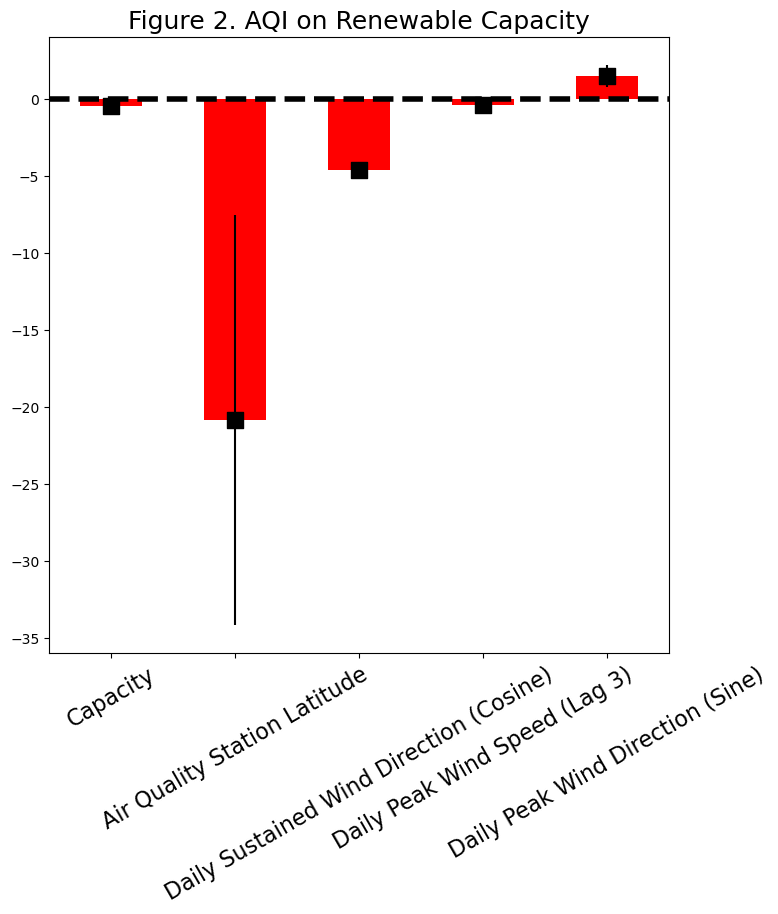

In [200]:
fig, ax = plt.subplots(figsize=(8, 8))
coef_df.plot(x='varname', y='coef', kind='bar', 
             ax=ax, color='red', 
             yerr='err', legend=False)
ax.set_ylabel('')
ax.set_xlabel('')
ax.scatter(x=np.arange(coef_df.shape[0]), 
           marker='s', s=120, 
           y=coef_df['coef'], color='black')
ax.axhline(y=0, linestyle='--', color='black', linewidth=4)
_ = ax.set_xticklabels(coef_df['varname'],
                       rotation=30, fontsize=16)

ax.set_title("Figure 2. AQI on Renewable Capacity", fontsize=18)


# Combined Regression Output for PM Regressions:

In [267]:
m1 = OLS_PM_NUM
m2 = OLS_PM_CAP

removal_list = ["CO2 Mass (short tons)_lag3", "CO2 Mass (short tons)"]
covariates_list = list(filter(lambda x: x not in removal_list, sig_vars(m1)))

setup = Stargazer([m1,m2])
setup.title("<b>Table 5. Relationships between PM 2.5 and Renewable Generators: Number vs. Capacity (LASSO to Panel OLS)</b>")
setup.custom_columns(["Total Generators", "Capacity"], [1, 1])
setup.dependent_variable_name("Average PM 2.5 (micro grams/m^3)")
setup.covariate_order(['Capacity'] + covariates_list)  # Only include significant variables in the table
setup.rename_covariates(rename_dict)

setup.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
setup.show_degrees_of_freedom(False)

# Ellipsis for omitted variables:
setup.add_line("...", ["...", "..."])
#Adding fixed effects indicator: 
setup.add_line(
    "Fixed effects",
    ["Yes", "Yes"],
    LineLocation.FOOTER_TOP,
)
setup.add_line(
    "Standard errors",
    ["Robust (HC1)", "Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
setup.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Fixed effects for Climate Station and Year included",
])

setup

# AQI Models 

In [ ]:
m1 = OLS_AQI_NUM
m2 = OLS_AQI_CAP
m3 = OLS_AQI_NUM_AQ
m4 = OLS_AQI_CAP_AQ

#Shortening the list of covariates:
removal_list = ["CO2 Mass (short tons)_lag3", "CO2 Mass (short tons)", "DailyMinimumDryBulbTemperature", "Daily Peak Wind Direction (Sine)",
                "AQlongitude", "Daily Sustained Wind Direction (Cosine)"]
covariates_list = list(filter(lambda x: x not in removal_list, sig_vars(m1)))
# covariates_list = sig_vars(m1)

setup2 = Stargazer([m1,m2,m3,m4])
setup2.title("<b>Table 6. Relationships between AQI and Renewable Generators: (LASSO to Panel OLS)</b>")

setup2.custom_columns(["Number", "Capacity", "Number 3-Way", "Capacity 3-Way"], [1,1,1,1])
setup2.dependent_variable_name("Average AQI")

setup2.covariate_order(['Capacity'] + covariates_list)  # Only include significant variables in the table
setup2.rename_covariates(rename_dict)
setup2.significance_levels([0.1, 0.05, 0.01])   # * p<0.1, ** p<0.05, *** p<0.01
setup2.show_degrees_of_freedom(False)

# Ellipsis for omitted variables:
setup2.add_line("...", ["...", "...", "...", "..."])

#Adding fixed effects indicator: 
setup2.add_line(
    "Two-Way Fixed Effects",
    ["Yes", "Yes","No","No"],
    LineLocation.FOOTER_TOP,
)
setup2.add_line(
    "Three-Way Fixed Effects",
    ['No','No','Yes','Yes'],
    LineLocation.FOOTER_TOP,
)
setup2.add_line(
    "Standard errors",
    ["Robust (HC1)", "Robust (HC1)", "Robust (HC1)", "Robust (HC1)"],
    LineLocation.FOOTER_TOP,
)
setup2.add_custom_notes([
    "Heteroskedasticity-robust standard errors in parentheses.",
    "Two-Way Fixed Effects for Climate Station and Year included",
    "Three-Way Fixed Effects for Climate Station, Year, and AQ Station included in Columns 3 and 4",
])

setup2

In [269]:
#Exporting tables as txt:
dir = '/Users/griffinberonio/Documents/AAE 724/Tables'
i = 0
for table in [setup, setup2]:
    i += 1
    table_name = f"Comparison_{i}"
    html_path = os.path.join(dir, f"{table_name}.tex")
    with open(html_path, 'w') as f:
        f.write(table.render_latex())